# Day 12 — Real Compressors Aren't Ideal: Back-Calculating Isentropic Efficiency
**Mahesha Gonal — Refrigeration Simulation Portfolio**

**Note on this version:** the original script printed three numbers but never charted them. This version adds a simple bar chart so the ideal-vs-real gap is visible at a glance, not just read off a printout.

**In plain terms:** every cycle calculation so far has assumed a "textbook" (isentropic) compressor — one with zero internal losses. Real compressors aren't like that; a datasheet gives an **EER** (Energy Efficiency Ratio) measured on a real unit, which already includes all the real-world friction, motor, and leakage losses. This notebook works *backwards* from a real datasheet number to find out exactly how far a real compressor falls short of the textbook ideal — the **isentropic efficiency**.

**Datasheet inputs used here:** R600a | T_evap = -23.3°C | T_cond = 40°C | Cooling capacity = 150 W | EER = 1.8

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

In [2]:
# CELL 2 — Imports
import CoolProp.CoolProp as CP
import matplotlib.pyplot as plt

In [3]:
# CELL 3 — Back-calculate isentropic efficiency from a real datasheet EER
refrigerant = "R600a"
T_evap_C = -23.3
T_cond_C = 40.0
Q_cooling_W = 150
EER_datasheet = 1.8

W_comp_actual = Q_cooling_W / EER_datasheet   # real electrical work the datasheet implies

T_evap = T_evap_C + 273.15
T_cond = T_cond_C + 273.15

P_evap = CP.PropsSI("P","T",T_evap,"Q",1,refrigerant)
P_cond = CP.PropsSI("P","T",T_cond,"Q",0,refrigerant)

h1 = CP.PropsSI("H","T",T_evap,"Q",1,refrigerant)
s1 = CP.PropsSI("S","T",T_evap,"Q",1,refrigerant)
h2 = CP.PropsSI("H","P",P_cond,"S",s1,refrigerant)   # ideal (isentropic) compressor exit
h3 = CP.PropsSI("H","T",T_cond,"Q",0,refrigerant)
h4 = h3

m_dot = Q_cooling_W / (h1 - h4)
h2_actual = h1 + (W_comp_actual / m_dot)              # real compressor exit, from datasheet work
eta_is = (h2 - h1) / (h2_actual - h1)

COP_ideal = (h1 - h4) / (h2 - h1)
COP_real  = (h1 - h4) / (h2_actual - h1)

print(f"Isentropic Efficiency = {eta_is*100:.2f}%")
print(f"Ideal COP = {COP_ideal:.3f}")
print(f"Real COP  = {COP_real:.3f}")

Isentropic Efficiency = 62.71%
Ideal COP = 2.870
Real COP  = 1.800


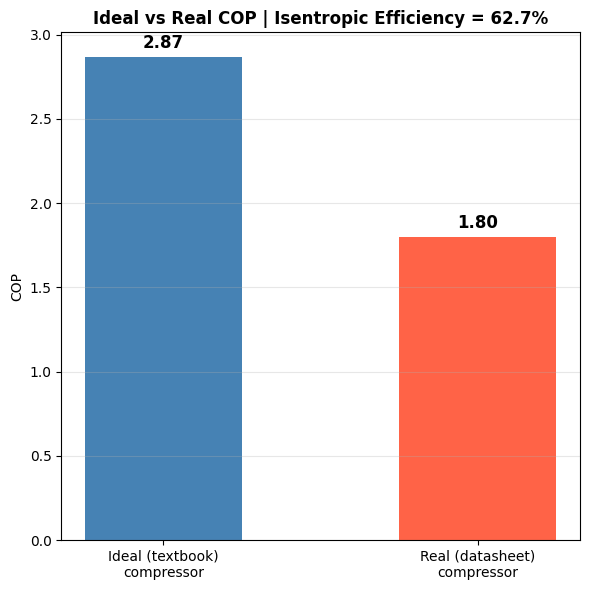

In [4]:
# CELL 4 — Bar chart: ideal vs real COP (the chart the original script was missing)
fig, ax = plt.subplots(figsize=(6,6))
bars = ax.bar(["Ideal (textbook)\ncompressor", "Real (datasheet)\ncompressor"],
              [COP_ideal, COP_real], color=["steelblue", "tomato"], width=0.5)
for bar, val in zip(bars, [COP_ideal, COP_real]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f"{val:.2f}",
            ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("COP")
ax.set_title(f"Ideal vs Real COP | Isentropic Efficiency = {eta_is*100:.1f}%", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("day12_ideal_vs_real_cop.png", dpi=150)
plt.show()

**What this chart tells us:** the gap between the two bars *is* the isentropic efficiency penalty — real compressors waste a meaningful share of their work as internal friction, motor losses, and re-expansion losses that a textbook isentropic calculation simply can't see. This back-calculation is exactly how an engineer turns a single EER number off a compressor datasheet into an efficiency figure that's actually usable inside a full cycle simulation — bridging the gap between "what the manufacturer claims" and "what the thermodynamics predicts."

In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day12_real_compressor_model.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Add Day 12 - real compressor isentropic efficiency (adds ideal vs real chart)", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Add Day 12 - real compressor isentropic efficiency (adds ideal vs real chart)", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")
